In [1]:
from pathlib import Path
import pandas as pd
pd.set_option('max_colwidth', 100)
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm, datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import confusion_matrix
import itertools
import scipy.stats as st
from scipy import stats
from sklearn.feature_selection import mutual_info_classif
#import seaborn as sns
#from matplotlib import pyplot as plt
#%matplotlib inline
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 500)
import rpy2
#import pingouin as pg
from itertools import combinations
import openpyxl
from contextlib import redirect_stdout
import random
import math
import seaborn as sns
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency, fisher_exact
from datetime import date, time, datetime
import csv

# Paths to data

In [2]:
# paths where to load files from
dat_dir = Path('../data/')
val_dir = dat_dir / 'ValSample'
fin_dir = dat_dir / 'finaldata'
log_dir = Path('./log')
log_dir.mkdir(exist_ok=True)
fin_dir.mkdir(exist_ok=True)
path_to_item_lookup = val_dir / 'Internalizing-Somatoform Items_DW.xlsx'
path_to_cogmood_questions = dat_dir / 'cogmood_questions.csv'
path_to_valsample = val_dir / 'inters23.xlsx'
path_to_codesheet = dat_dir / 'yougov_codesheet_alignment.tsv'
path_to_genpop = dat_dir / 'NIMH0007_genpop_num_OUTPUT.csv'
path_to_enriched = dat_dir / 'NIMH0007_mental_health_num_OUTPUT.csv'

# paths where to save preprocessed data files
path_save_val = fin_dir / 'dat_val.csv'
path_save_dat_gp_grid1st_norecontact = fin_dir / 'dat_gp_grid1st_norecontact.csv'
path_save_dat_en_grid1st_norecontact = fin_dir / 'dat_en_grid1st_norecontact.csv'
path_save_dat_gp_grid1st_full = fin_dir / 'dat_gp_grid1st_full.csv'
path_save_dat_en_grid1st_full = fin_dir / 'dat_en_grid1st_full.csv'
path_save_dat_gp_gridall_full = fin_dir / 'dat_gp_gridall_full.csv'
path_save_dat_en_gridall_full = fin_dir / 'dat_en_gridall_full.csv'
#path_save_dat_gp_gridall_recontact = '../../data/finaldata/dat_gp_gridall_recontact.csv'
#path_save_dat_en_gridall_recontact = '../../data/finaldata/dat_en_gridall_recontact.csv'

# 1 - Data load and process

## 1.1 - Functions

In [3]:
def make_hitop_list(data):
    # only hitop cols
    hitop_cols = []
    for c in data.columns:
        if 'hitop' in c and 'today' not in c:
            hitop_cols.append(c)   
    return(hitop_cols)

def make_recontact_list(data):
    list_recontact = []
    for c in data.columns:
        if 'recontact' in c:
            list_recontact.append(c)
    return(list_recontact)

def do_checks(dat, remove_checks):
    assert remove_checks in ['no', 'yes', 'grid', 'gridinitialvisitonly']
    dat['passed_checks'] = True
    dat['passed_grid'] = True
    dat['passed_grid_initialonly'] = True
    dat['passed_list'] = True
    dat.loc[dat.check_moderately != 3, 'passed_checks'] = False
    dat.loc[dat.check_notatall != 1, 'passed_checks'] = False
    dat.loc[dat.check_moderately != 3, 'passed_grid'] = False
    dat.loc[dat.check_notatall != 1, 'passed_grid'] = False
    dat.loc[dat.todaycheck_1 != 1, 'passed_checks'] = False
    dat.loc[dat.todaycheck_2 != 1, 'passed_checks'] = False
    dat.loc[dat.todaycheck_1 != 1, 'passed_list'] = False
    dat.loc[dat.todaycheck_2 != 1, 'passed_list'] = False
    # deal with attention checks - recontact
    dat['passed_checks_recontact'] = True
    dat['passed_grid_recontact'] = True
    dat['passed_list_recontact'] = True
    dat.loc[dat.check_moderately_recontact != 3, 'passed_checks_recontact'] = False
    dat.loc[dat.check_notatall_recontact != 1, 'passed_checks_recontact'] = False
    dat.loc[dat.check_moderately_recontact != 3, 'passed_grid_recontact'] = False
    dat.loc[dat.check_notatall_recontact != 1, 'passed_grid_recontact'] = False
    dat.loc[dat.todaycheck_1_recontact != 1, 'passed_checks_recontact'] = False
    dat.loc[dat.todaycheck_2_recontact != 1, 'passed_checks_recontact'] = False
    dat.loc[dat.todaycheck_1_recontact != 1, 'passed_list_recontact'] = False
    dat.loc[dat.todaycheck_2_recontact != 1, 'passed_list_recontact'] = False
    
    #print('checks_initial:')
    #print(1 - dat.loc[:, ['passed_checks', 'passed_grid', 'passed_list']].mean())
    print('\non intial visit')
    print('\nThis is how many ppl passed attention checks:')
    print('Calculated as 1 - dat.loc[:, [\'passed_checks\', \'passed_grid\', \'passed_list\']].mean()')
    print(1 - dat.loc[:, ['passed_checks', 'passed_grid', 'passed_list']].mean())
    how_many_passed_checks = dat['passed_checks'].value_counts()[True]
    how_many_failed_checks = dat['passed_checks'].value_counts()[False]
    how_many_passed_grid = dat['passed_grid'].value_counts()[True]
    how_many_failed_grid = dat['passed_grid'].value_counts()[False]
    how_many_passed_list = dat['passed_list'].value_counts()[True]
    how_many_failed_list = dat['passed_list'].value_counts()[False]
    how_many_overall = dat.shape[0]
    print('\nPassed checks: %d out of %d' % (how_many_passed_checks, how_many_overall))
    print('Failed checks: %d out of %d' % (how_many_failed_checks, how_many_overall))
    print('Passed grid: %d out of %d' % (how_many_passed_grid, how_many_overall))
    print('Failed grid: %d out of %d' % (how_many_failed_grid, how_many_overall))
    print('Passed list: %d out of %d' % (how_many_passed_list, how_many_overall))
    print('Failed list: %d out of %d' % (how_many_failed_list, how_many_overall))
    
    print('\non recontact visit:')
    #print(1 - dat.loc[:, ['passed_checks_recontact', 'passed_grid_recontact', 'passed_list_recontact']].mean()) 
    how_many_passed_checks_recontact = dat['passed_checks_recontact'].value_counts()[True]
    how_many_failed_checks_recontact = dat['passed_checks_recontact'].value_counts()[False]
    how_many_passed_grid_recontact = dat['passed_grid_recontact'].value_counts()[True]
    how_many_failed_grid_recontact = dat['passed_grid_recontact'].value_counts()[False]
    print('\nPassed checks: %d out of %d' % (how_many_passed_checks_recontact, how_many_overall))
    print('Failed checks: %d out of %d' % (how_many_failed_checks_recontact, how_many_overall))
    print('Passed grid: %d out of %d' % (how_many_passed_grid_recontact, how_many_overall))
    print('Failed grid: %d out of %d' % (how_many_failed_grid_recontact, how_many_overall))
    
    if remove_checks == 'yes':
        print('removing checks')
        dat = dat.loc[dat['passed_checks'] == True]
        dat = dat.loc[dat['passed_checks_recontact'] == True]
    elif remove_checks == 'grid':
        print('removing checks')
        dat = dat.loc[dat['passed_grid'] == True]
        dat = dat.loc[dat['passed_grid_recontact'] == True]
    elif remove_checks == 'gridinitialvisitonly':
        print('removing checks')
        dat = dat.loc[dat['passed_grid'] == True]
    print(dat.shape)
    print('done removing checks')        
    return(dat)

def load_item_lookup():
    # this is a table that aligns scale items with their corresponding questions
    htqs = pd.read_excel(path_to_item_lookup, skiprows=2,
                                names=['id', 'scale', 'item', '_0', '_1', '_2', '_3']).drop(['_0', '_1', '_2', '_3'], axis=1)
    # cmqs is a dataframe with items and responses
    # htcm is the same dataframe, but only displaying HiTOP items
    cmqs = pd.read_csv(path_to_cogmood_questions)
    cmqs = cmqs.rename({'Unnamed: 0': 'id'}, axis=1)
    htcm = cmqs.query("measure == 'HiTOP'")
    # this is a lookup table for subscales, items (sentence questions), and hitop ids
    item_lookup = htcm.loc[:, ['id','subscale', 'item']].merge(htqs.loc[:, ['id','item']], how='inner', on='item', suffixes=['_cm', '_ht'])
    item_lookup['htid'] = 'hitop'+ item_lookup.id_ht.astype(str)
    return(item_lookup)
    
def load_valsample():
    # VALIDATION SAMPLE - main dataframe with responses
    dat_validation = pd.read_excel(path_to_valsample)
    '''resp_cols = responses.columns[responses.columns.isin(item_lookup.htid)]
    # scale scores
    scale_scores = []
    for ss, df in item_lookup.groupby('subscale'):
        tmp = responses.loc[:, df.htid].sum(axis=1)
        tmp.name = ss.replace(" ", "_").replace("/", "_").replace("-", "_")
        scale_scores.append(tmp)
    scale_scores = pd.concat(scale_scores, axis=1)
    scale_names = list(scale_scores.columns.values)'''
    #do_checks(dat_validation)    
    # this is the validation data to be used
    hitop_cols_list = make_hitop_list(dat_validation)
    data_validation = dat_validation[hitop_cols_list]
    data_validation = data_validation.assign(whichdata=['validation']*data_validation.shape[0])
    return(dat_validation, data_validation)

def do_codesheet():
    #loads the codesheet file
    # wherever the emane column exists, creates a dict variablename:ename
    code_book = pd.read_csv(path_to_codesheet, sep='\t')
    ename_lut = {vn:en for vn, en in code_book.loc[code_book.ename.notnull(), ['var_name', 'ename']].values}
    for vn, en in code_book.loc[code_book.ename.notnull(), ['var_name', 'ename']].values:
        ename_lut[vn+'_recontact'] = en+'_recontact'
    tmp = code_book.query('ename.notnull()')
    scale_lut = {}
    for ss, df in tmp.loc[tmp.ename.str.contains('hitop') & ~tmp.ename.str.contains('today')].groupby('subscale'):
        scale_name = ss.replace(" ", "_").replace("/", "_").replace("-", "_")
        items = df.ename.values
        scale_lut[scale_name] = items    
     #   scale_name_initial = scale_name+'_initial'
     #   scale_lut[scale_name_initial] = items 
        scale_name_recontact = scale_name+'_recontact'
        items_recontact = []
        for item in items:
            items_recontact.append(item+'_recontact')
        scale_lut[scale_name_recontact] = np.array(items_recontact, dtype=object)
    # rename checks
    ename_lut['FNM_Q8_5'] ='check_moderately'
    ename_lut['FNM_Q22_3'] ='check_notatall'
    ename_lut['FNM_Q42_m_10'] ='todaycheck_1'
    ename_lut['FNM_44_m_28'] ='todaycheck_2'
    ename_lut['FNM_Q8_5_recontact'] ='check_moderately_recontact'
    ename_lut['FNM_Q22_3_recontact'] ='check_notatall_recontact'
    ename_lut['FNM_Q42_m_10_recontact'] ='todaycheck_1_recontact'
    ename_lut['FNM_44_m_28_recontact'] ='todaycheck_2_recontact'
    return ename_lut, scale_lut

def clean_mood_diagnosis(dat):
    # clean mood diagnosis
    dat['mood_dx'] = ''
    dat['n_mood_dx'] = (dat.loc[:, ['FNM_Q25_1', 'FNM_Q25_2', 'FNM_Q25_3', 'FNM_Q25_4', 'FNM_Q25_5', 'FNM_Q25_6']]==1).sum(axis=1)
    dat.loc[dat.FNM_Q25_955 == 1, 'mood_dx'] = 'other'
    dat.loc[dat.FNM_Q25_1 == 1, 'mood_dx'] = 'mdd'
    dat.loc[dat.FNM_Q25_2 == 1, 'mood_dx'] = 'persistent'
    dat.loc[dat.FNM_Q25_3 == 1, 'mood_dx'] = 'premenstrual'
    dat.loc[dat.FNM_Q25_4 == 1, 'mood_dx'] = 'bipolarI'
    dat.loc[dat.FNM_Q25_5 == 1, 'mood_dx'] = 'bipolarII'
    dat.loc[dat.FNM_Q25_6 == 1, 'mood_dx'] = 'cyclothymic'
    dat.loc[dat.n_mood_dx > 1, 'mood_dx'] = 'multiple'
    # clean other mood columns
    dat.loc[dat.mood_years == 999, 'mood_years'] = np.nan
    dat['mood_bothered']=False
    dat.loc[dat.mood_bothered_orig == 1, 'mood_bothered'] = True
    return(dat)

def clean_mood_diagnosis_recontact(dat):
    # clean mood diagnosis - recontact
    dat['mood_dx_recontact'] = ''
    dat['n_mood_dx_recontact'] = (dat.loc[:, ['FNM_Q25_1_recontact', 'FNM_Q25_2_recontact', 'FNM_Q25_3_recontact', 'FNM_Q25_4_recontact', 'FNM_Q25_5_recontact', 'FNM_Q25_6_recontact']]==1).sum(axis=1)
    dat.loc[dat.FNM_Q25_955_recontact == 1, 'mood_dx_recontact'] = 'other'
    dat.loc[dat.FNM_Q25_1_recontact == 1, 'mood_dx_recontact'] = 'mdd'
    dat.loc[dat.FNM_Q25_2_recontact == 1, 'mood_dx_recontact'] = 'persistent'
    dat.loc[dat.FNM_Q25_3_recontact == 1, 'mood_dx_recontact'] = 'premenstrual'
    dat.loc[dat.FNM_Q25_4_recontact == 1, 'mood_dx_recontact'] = 'bipolarI'
    dat.loc[dat.FNM_Q25_5_recontact == 1, 'mood_dx_recontact'] = 'bipolarII'
    dat.loc[dat.FNM_Q25_6_recontact == 1, 'mood_dx_recontact'] = 'cyclothymic'
    dat.loc[dat.n_mood_dx_recontact > 1, 'mood_dx_recontact'] = 'multiple'
    # clean other mood columns - recontact
    # clean other mood columns
    dat.loc[dat.mood_years_recontact == 999, 'mood_years_recontact'] = np.nan
    dat['mood_bothered_recontact']=False
    dat.loc[dat.mood_bothered_recontact_orig == 1, 'mood_bothered_recontact'] = True
    return(dat)

def clean_anxiety_diagnosis(dat):
    # clean anxiety diagnosis
    dat['anxiety_dx'] = ''
    dat['n_anxiety_dx'] = (dat.loc[:, ['FNM_Q30_m_1',
                                       'FNM_Q30_m_2',
                                       'FNM_Q30_m_3', 
                                       'FNM_Q30_m_4', 
                                       'FNM_Q30_m_5',
                                       'FNM_Q30_m_6',
                                       'FNM_Q30_m_7',
                                       'FNM_Q30_m_8',]]==1).sum(axis=1)
    dat.loc[dat.FNM_Q30_m_955 == 1, 'anxiety_dx'] = 'other'
    dat.loc[dat.FNM_Q30_m_1 == 1, 'anxiety_dx'] = 'gad'
    dat.loc[dat.FNM_Q30_m_2 == 1, 'anxiety_dx'] = 'separation'
    dat.loc[dat.FNM_Q30_m_3 == 1, 'anxiety_dx'] = 'agoraphobia'
    dat.loc[dat.FNM_Q30_m_4 == 1, 'anxiety_dx'] = 'phobia'
    dat.loc[dat.FNM_Q30_m_5 == 1, 'anxiety_dx'] = 'social'
    dat.loc[dat.FNM_Q30_m_6 == 1, 'anxiety_dx'] = 'panic_disorder'
    dat.loc[dat.FNM_Q30_m_7 == 1, 'anxiety_dx'] = 'panic_attack'
    dat.loc[dat.FNM_Q30_m_8 == 1, 'anxiety_dx'] = 'mutism'
    dat.loc[dat.n_anxiety_dx > 1, 'anxiety_dx'] = 'multiple'
    # clean other anxiety columns
    dat.loc[dat.anxiety_years == 999, 'anxiety_years'] = np.nan
    dat['anxiety_bothered']=False
    dat.loc[dat.anxiety_bothered_orig == 1, 'anxiety_bothered'] = True
    return(dat)

def clean_anxiety_diagnosis_recontact(dat):
    # clean anxiety diagnosis - recontact
    dat['anxiety_dx_recontact'] = ''
    dat['n_anxiety_dx_recontact'] = (dat.loc[:, ['FNM_Q30_m_1_recontact',
                                       'FNM_Q30_m_2_recontact',
                                       'FNM_Q30_m_3_recontact', 
                                       'FNM_Q30_m_4_recontact', 
                                       'FNM_Q30_m_5_recontact',
                                       'FNM_Q30_m_6_recontact',
                                       'FNM_Q30_m_7_recontact',
                                       'FNM_Q30_m_8_recontact',]]==1).sum(axis=1)
    dat.loc[dat.FNM_Q30_m_955_recontact == 1, 'anxiety_dx_recontact'] = 'other'
    dat.loc[dat.FNM_Q30_m_1_recontact == 1, 'anxiety_dx_recontact'] = 'gad'
    dat.loc[dat.FNM_Q30_m_2_recontact == 1, 'anxiety_dx_recontact'] = 'separation'
    dat.loc[dat.FNM_Q30_m_3_recontact == 1, 'anxiety_dx_recontact'] = 'agoraphobia'
    dat.loc[dat.FNM_Q30_m_4_recontact == 1, 'anxiety_dx_recontact'] = 'phobia'
    dat.loc[dat.FNM_Q30_m_5_recontact == 1, 'anxiety_dx_recontact'] = 'social'
    dat.loc[dat.FNM_Q30_m_6_recontact == 1, 'anxiety_dx_recontact'] = 'panic_disorder'
    dat.loc[dat.FNM_Q30_m_7_recontact == 1, 'anxiety_dx_recontact'] = 'panic_attack'
    dat.loc[dat.FNM_Q30_m_8_recontact == 1, 'anxiety_dx_recontact'] = 'mutism'
    
    dat.loc[dat.n_anxiety_dx_recontact > 1, 'anxiety_dx_recontact'] = 'multiple'
    # clean other anxiety columns - recontact
    dat.loc[dat.anxiety_years_recontact == 999, 'anxiety_years_recontact'] = np.nan
    dat['anxiety_bothered_recontact']=False
    dat.loc[dat.anxiety_bothered_recontact_orig == 1, 'anxiety_bothered_recontact'] = True
    return(dat)

def clean_attnt_dx(dat):
    # clean attention diagnosis
    dat['attention_dx'] = ''
    dat['n_attention_dx'] = (dat.loc[:, ['FNM_Q35_m_1',
                                       'FNM_Q35_m_2',
                                      ]]==1).sum(axis=1)
    dat.loc[dat.FNM_Q35_m_3 == 1, 'attention_dx'] = 'other'
    dat.loc[dat.FNM_Q35_m_1 == 1, 'attention_dx'] = 'adhd'
    dat.loc[dat.FNM_Q35_m_2 == 1, 'attention_dx'] = 'adhd'
    
    # clean other attention columns
    dat.loc[dat.attention_years == 999, 'attention_years'] = np.nan
    dat['attention_bothered']=False
    dat.loc[dat.attention_bothered_orig == 1, 'attention_bothered'] = True
    return(dat)

def clean_attnt_dx_recontact(dat):
    # clean attention diagnosis - recontact
    dat['attention_dx_recontact'] = ''
    dat['n_attention_dx_recontact'] = (dat.loc[:, ['FNM_Q35_m_1_recontact',
                                       'FNM_Q35_m_2_recontact',
                                      ]]==1).sum(axis=1)
    dat.loc[dat.FNM_Q35_m_3_recontact == 1, 'attention_dx_recontact'] = 'other'
    dat.loc[dat.FNM_Q35_m_1_recontact == 1, 'attention_dx_recontact'] = 'adhd'
    dat.loc[dat.FNM_Q35_m_2_recontact == 1, 'attention_dx_recontact'] = 'adhd'
    
    # clean other attention columns - recontact
    dat.loc[dat.attention_years_recontact == 999, 'attention_years_recontact'] = np.nan
    dat['attention_bothered_recontact']=False
    dat.loc[dat.attention_bothered_recontact_orig == 1, 'attention_bothered_recontact'] = True
    return(dat)

def define_attnt_checks(dat):
    # deal with attention checks 
    dat['passed_checks'] = True
    dat['passed_grid'] = True
    dat['passed_list'] = True
    dat.loc[dat.check_moderately != 3, 'passed_checks'] = False
    dat.loc[dat.check_notatall != 1, 'passed_checks'] = False
    dat.loc[dat.check_moderately != 3, 'passed_grid'] = False
    dat.loc[dat.check_notatall != 1, 'passed_grid'] = False
    dat.loc[dat.todaycheck_1 != 1, 'passed_checks'] = False
    dat.loc[dat.todaycheck_2 != 1, 'passed_checks'] = False
    dat.loc[dat.todaycheck_1 != 1, 'passed_list'] = False
    dat.loc[dat.todaycheck_2 != 1, 'passed_list'] = False 
    # deal with attention checks - recontact
    dat['passed_checks_recontact'] = True
    dat['passed_grid_recontact'] = True
    dat['passed_list_recontact'] = True
    dat.loc[dat.check_moderately_recontact != 3, 'passed_checks_recontact'] = False
    dat.loc[dat.check_notatall_recontact != 1, 'passed_checks_recontact'] = False
    dat.loc[dat.check_moderately_recontact != 3, 'passed_grid_recontact'] = False
    dat.loc[dat.check_notatall_recontact != 1, 'passed_grid_recontact'] = False
    dat.loc[dat.todaycheck_1_recontact != 1, 'passed_checks_recontact'] = False
    dat.loc[dat.todaycheck_2_recontact != 1, 'passed_checks_recontact'] = False
    dat.loc[dat.todaycheck_1_recontact != 1, 'passed_list_recontact'] = False
    dat.loc[dat.todaycheck_2_recontact != 1, 'passed_list_recontact'] = False
    # how many passed checks?
    print('\nThis is how many ppl passed attention checks:')
    print('Calculated as 1 - dat.loc[:, [\'passed_checks\', \'passed_grid\', \'passed_list\']].mean()')
    print(1 - dat.loc[:, ['passed_checks', 'passed_grid', 'passed_list']].mean())
    print('Same for recontact:')
    print(1 - dat.loc[:, ['passed_checks_recontact', 'passed_grid_recontact', 'passed_list_recontact']].mean())
    return(dat)
    
def load_data(dataname, doing_checks, doing_remove_checks, rescore=True):
    '''
    doing_checks always needs to be true because that's where we tidy up the checks data
    '''
    print(doing_remove_checks)
    assert(dataname in ['genpop','enriched'])
    
    #codesheet file
    ename_lut, scale_lut = do_codesheet()
    
    # done working with the codesheet file, now opening the actual data
    if dataname == 'genpop':
        datapath = path_to_genpop
    elif dataname == 'enriched':
        datapath = path_to_enriched
    dat = pd.read_csv(datapath, dtype={'caseid':str}, engine='python')
    if dataname == 'genpop':
        # ONLY GENPOP drop the .0 that pandas appends for some reason - only for genpop
        dat['caseid'] = dat.caseid.str[:-2]
    
    #renaming columns
    dat = dat.rename(ename_lut, axis=1)
    dat = dat.rename(columns={
        'mood_bothered': 'mood_bothered_orig',
        'mood_bothered_recontact': 'mood_bothered_recontact_orig',
        'anxiety_bothered': 'anxiety_bothered_orig',
        'anxiety_bothered_recontact': 'anxiety_bothered_recontact_orig',
        'attention_bothered': 'attention_bothered_orig',
        'attention_bothered_recontact': 'attention_bothered_recontact_orig'}) 

    # degfag dataframe
    dat = dat.copy()

    # clean diagnoses
    dat = clean_mood_diagnosis(dat)
    dat = clean_mood_diagnosis_recontact(dat)
    dat = clean_anxiety_diagnosis(dat)
    dat = clean_anxiety_diagnosis_recontact(dat)
    dat = clean_attnt_dx(dat)
    dat = clean_attnt_dx_recontact(dat)
    
    if doing_checks:
        dat = do_checks(dat = dat, remove_checks = doing_remove_checks) 
    '''
    minus_1_cols = []
    # only baars, gad, phq
    minus_one_stems = ['inattention', 'hyperactivity', 'impulsivity', 'sct', 'gad', 'phq','inattention_recontact', 'hyperactivity_recontact', 'impulsivity_recontact', 'sct_recontact', 'gad_recontact', 'phq_recontact']
    for ms in m1_stems:
        #print(ms)
        if "recontact" not in ms:
            cols = list(dat.columns[dat.columns.str.contains(ms) & ~dat.columns.str.contains('today') & ~dat.columns.str.contains('sum') & ~dat.columns.str.contains('recontact')].values)
        else:
            cols = list(dat.columns[dat.columns.str.contains(ms[:-10]) & ~dat.columns.str.contains('today') & ~dat.columns.str.contains('sum') & dat.columns.str.contains('recontact')].values)
        #print(cols)
        minus_1_cols.extend(cols)

    #debug line
    print("\n\n ++++++++++++++ MINUS ONE COLUMNS ++++++++++++++ ")
    print(minus_1_cols)

    # why are we doing this
    # subtract 1 from responses
    dat.loc[:, minus_1_cols] -= 1
    '''

    # begin rescoring gad, baars, gad
    if rescore:
        minus_1_cols = []
        # only baars, gad, phq
        minus_one_stems = ['inattention', 'hyperactivity', 'impulsivity', 'sct', 'gad', 'phq','inattention_recontact', 'hyperactivity_recontact', 'impulsivity_recontact', 'sct_recontact', 'gad_recontact', 'phq_recontact']
        for my_ms in minus_one_stems:
            if "recontact" not in my_ms:
                # my_cols = cols that contain that stem BUT ARE NOT "today" or "sum" or "recontact
                my_cols = list(dat.columns[dat.columns.str.contains(my_ms) & ~dat.columns.str.contains('today') & ~dat.columns.str.contains('sum') & ~dat.columns.str.contains('recontact')].values)
            else:       
                # my_cols = cols that contain step AND "recontact" BUT NOT "today" or "sum
                my_cols = list(dat.columns[dat.columns.str.contains(my_ms[:-10]) & ~dat.columns.str.contains('today') & ~dat.columns.str.contains('sum') & dat.columns.str.contains('recontact')].values)
            minus_1_cols.extend(my_cols)
        # subtract 1 from responses
        dat.loc[:, minus_1_cols] -= 1            
    # -- end rescoring gad, baars, gad --
    
    m1_stems = ['inattention', 'hyperactivity', 'impulsivity', 'sct', 'gad', 'phq', 'hitop',
           'inattention_recontact', 'hyperactivity_recontact', 'impulsivity_recontact', 'sct_recontact', 'gad_recontact', 'phq_recontact', 'hitop_recontact']
    # # summing up the values
    sum_cols = []
    for ms in m1_stems:
        if 'hitop' not in ms:
            if "recontact" not in ms:
                cols = list(dat.columns[dat.columns.str.contains(ms) & ~dat.columns.str.contains('today') & ~dat.columns.str.contains('sum') & ~dat.columns.str.contains('recontact')].values)
                dat[f'{ms}_sum'] = dat.loc[:, cols].sum(axis=1)
                sum_cols.append(ms + '_sum')
            else:
                cols = list(dat.columns[dat.columns.str.contains(ms[:-10]) & ~dat.columns.str.contains('today') & ~dat.columns.str.contains('sum') & dat.columns.str.contains('recontact')].values)
                dat[f'{ms[:-10]}_sum_recontact'] = dat.loc[:, cols].sum(axis=1)
                sum_cols.append(ms[:-10] + '_sum_recontact')  
    #original code written by mariezelenina
    # hitop_sums = []
    # for scale_name, items in scale_lut.items():
    #     dat[scale_name] = dat.loc[:, items].sum(1) # adding a dat[scale_name] with a sum of all values ("items)"
    #     hitop_sums.append(scale_name)   

    # sum = 0
    # for scale_name, items in scale_lut.items():
    #     if "well_being" not in scale_name:
    #         sum += len(items)

    # # !!!!!!!!!! double-check this
    # dat['hitop_sum'] = dat.loc[:, hitop_sums[::2][:-1]].sum(1)  # [:-1] because we don't include the well-being scale
    # dat['hitop_sum_recontact'] = dat.loc[:, hitop_sums[1::2][:-1]].sum(1)
    # code from Claude (Opus 4.7 adaptive) fixing the potentially brittle code above
    # Compute per-subscale sums. Keep `hitop_sums` populated because
    # downstream code (column renaming, `my_columns` construction) uses it.
    hitop_sums = []
    for scale_name, items in scale_lut.items():
        dat[scale_name] = dat.loc[:, items].sum(axis=1)
        hitop_sums.append(scale_name)

    # HiTOP total = sum across subscale sums, excluding well-being (per the
    # prereg "Indices" section). Filter by explicit name pattern rather
    # than positional slicing of `hitop_sums`. The previous version
    # (`hitop_sums[::2][:-1]`) silently depended on (a) initial and
    # recontact entries strictly alternating in scale_lut and (b)
    # well_being sorting last in dict-iteration order. Both are currently
    # true but would break under any refactor of scale_lut.
    initial_subscale_cols = [
        name for name in hitop_sums
        if 'well_being' not in name and not name.endswith('_recontact')
    ]
    recontact_subscale_cols = [
        name for name in hitop_sums
        if 'well_being' not in name and name.endswith('_recontact')
    ]

    # Defensive: the two lists must be the same length and (after
    # stripping the suffix) name-aligned. If this assertion ever fires,
    # scale_lut has drifted out of the assumed shape.
    assert len(initial_subscale_cols) == len(recontact_subscale_cols), (
        f"Initial/recontact subscale count mismatch: "
        f"{len(initial_subscale_cols)} vs {len(recontact_subscale_cols)}"
    )
    assert [c + '_recontact' for c in initial_subscale_cols] == recontact_subscale_cols, (
        "Initial and recontact subscale columns are not name-aligned: "
        f"{initial_subscale_cols} vs {recontact_subscale_cols}"
    )

    dat['hitop_sum']            = dat.loc[:, initial_subscale_cols].sum(axis=1)
    dat['hitop_sum_recontact']  = dat.loc[:, recontact_subscale_cols].sum(axis=1)
    # end inserted code from Claude
    dat['baars_sum'] = dat.inattention_sum + dat.hyperactivity_sum + dat.impulsivity_sum
    dat['baars_sum_recontact'] = dat.inattention_sum_recontact + dat.hyperactivity_sum_recontact + dat.impulsivity_sum_recontact
    dat['moodanxiety_bothered'] = dat.mood_bothered | dat.anxiety_bothered
    dat['moodanxiety_bothered_recontact'] = dat.mood_bothered_recontact | dat.anxiety_bothered_recontact
    dep_scales = [
    'anhedonic_depression',
    'appetite_gain',
    'appetite_loss',
    'cognitive_problems',
    'hyposomnia',
    'indecisiveness',
    'insomnia',
    'shame_guilt',
    ]
    anx_scales = [
        'anxious_worry',
        'panic',
        'separation_insecurity',
        'situational_phobia',
        'social_anxiety'
    ]
    dat['hitop_all_depression'] = dat.loc[:, dep_scales].sum(axis=1)
    dat['hitop_all_depression_recontact'] = dat.loc[:, [ss + '_recontact' for ss in dep_scales]].sum(axis=1)
    dat['hitop_all_anxiety'] = dat.loc[:, anx_scales].sum(axis=1)
    dat['hitop_all_anxiety_recontact'] = dat.loc[:, [ss + '_recontact' for ss in anx_scales]].sum(axis=1)
        
    my_columns = []
    for item in ['hitop_sum', 'baars_sum', 'phq_sum', 'gad_sum', # all sums
                 'mood_bothered','anxiety_bothered', 'attention_bothered', 'moodanxiety_bothered', # bothered
                 'inattention_sum', 'hyperactivity_sum', 'impulsivity_sum', 'sct_sum']: # each subscale of baars
        my_columns.append(item)
        my_columns.append(item+'_recontact')
    my_columns.extend(hitop_sums) #each subscale of hitop

    # rename columns with phq and gad sums for cnsistency in naming
    dat = dat.rename(columns={"gad_recontact_sum": "gad_sum_recontact", "phq_recontact_sum": "phq_sum_recontact"})

    # rename baars subscales
    dat = dat.rename(columns={"inattention_sum": "baars_inattention_sum", 
                          "inattention_sum_recontact": "baars_inattention_sum_recontact",
                          "hyperactivity_sum": "baars_hyperactivity_sum", 
                          "hyperactivity_sum_recontact": "baars_hyperactivity_sum_recontact",
                          "impulsivity_sum": "baars_impulsivity_sum", 
                          "impulsivity_sum_recontact": "baars_impulsivity_sum_recontact",
                          "sct_sum": "baars_sct_sum",
                          "sct_sum_recontact": "baars_sct_sum_recontact"})

    # rename hitops subscales
    rename_dict = {}
    for hitop_item in hitop_sums:
        rename_dict[hitop_item] = 'hitop_' + hitop_item
    dat = dat.rename(columns=rename_dict)
    
    hitop_cols_list = make_hitop_list(dat)
    dat = dat.assign(whichdata=[dataname]*dat.shape[0])
    
    data = dat[hitop_cols_list]
    data = data.assign(whichdata=[dataname]*data.shape[0])
    recontact_cols_list = make_recontact_list(data)
    data_norecontact = data.drop(columns=recontact_cols_list)
    return dat, data, data_norecontact   

def prep_data_recontactanalysis(dataframe_withrecontact):
    df = dataframe_withrecontact
    df_helper = df.copy(deep=True)
    df_rows = df.shape[0]
    df = df.assign(whichvisit=['initialvisit']*df_rows)
    df_helper = df_helper.assign(whichvisit=['recontactvisit']*df_rows)
    # in df, drop all "recontact" columns
    # in df_helper, drop all initial visit columns, then rename the recontact columns
    cols_recontact = []
    cols_original = []
    for c in df.columns:
        if "recontact" in c:
            cols_recontact.append(c)
            cols_original.append(c[:-10])  
    df = df.drop(columns=cols_recontact)
    df_helper = df_helper.drop(columns=cols_original)
    cols_dict = {}
    for cname in cols_recontact:
        cols_dict[cname] = cname[:-10]
    # rename cols in df_helper
    df_helper.rename(columns=cols_dict, inplace=True)    
    mydata_withrecontact = pd.concat([df, df_helper])
    return(mydata_withrecontact)

## 1.2 Validation data - Load, process and save

In [4]:
# Load item_lookup
item_lookup = load_item_lookup()

# Load validation data 
(data_val_full, data_val) = load_valsample()

data_val.to_csv(path_save_val)

/Users/nielsond/code/hitop_val/HiTOP/.pixi/envs/default/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [5]:
# check how val is coded
for c in data_val.columns:
    print(f'\n\n{c}\n')
    print(f'min: {data_val[c].min()}, max: {data_val[c].max()}')



hitop39

min: 1, max: 4


hitop77

min: 1, max: 4


hitop84

min: 1, max: 4


hitop92

min: 1, max: 4


hitop93

min: 1, max: 4


hitop123

min: 1, max: 4


hitop157

min: 1, max: 4


hitop182

min: 1, max: 4


hitop230

min: 1, max: 4


hitop246

min: 1, max: 4


hitop20

min: 1, max: 4


hitop34

min: 1, max: 4


hitop89

min: 1, max: 4


hitop203

min: 1, max: 4


hitop240

min: 1, max: 4


hitop248

min: 1, max: 4


hitop265

min: 1, max: 4


hitop120

min: 1, max: 4


hitop141

min: 1, max: 4


hitop243

min: 1, max: 4


hitop275

min: 1, max: 4


hitop109

min: 1, max: 4


hitop280

min: 1, max: 4


hitop283

min: 1, max: 4


hitop67

min: 1, max: 4


hitop142

min: 1, max: 4


hitop159

min: 1, max: 4


hitop189

min: 1, max: 4


hitop5

min: 1, max: 4


hitop66

min: 1, max: 4


hitop99

min: 1, max: 4


hitop181

min: 1, max: 4


hitop231

min: 1, max: 4


hitop21

min: 1, max: 4


hitop90

min: 1, max: 4


hitop95

min: 1, max: 4


hitop160

min: 1, max: 4


hitop254

min: 

## 1.3 Data for CFA and conv/div - remove grid 1st visit only - Load, process and save

In [6]:
# --- FOR CFA and conv/div - remove grid checks on 1st visit only ---

# Load genpop data
print('\n Process GP data')
data_genpop_full_grid1st, data_genpop_grid1st, data_genpop_norecontact_grid1st = load_data('genpop', doing_checks = True, doing_remove_checks='gridinitialvisitonly', rescore=True)

# Load enriched data
print('\n Process EN data')
data_enriched_full_grid1st, data_enriched_grid1st, data_enriched_norecontact_grid1st = load_data('enriched', doing_checks = True, doing_remove_checks='gridinitialvisitonly', rescore=True)

# save for cfa
data_genpop_norecontact_grid1st.to_csv(path_save_dat_gp_grid1st_norecontact)
data_enriched_norecontact_grid1st.to_csv(path_save_dat_en_grid1st_norecontact)

#save for conv/div
data_genpop_full_grid1st.to_csv(path_save_dat_gp_grid1st_full)
data_enriched_full_grid1st.to_csv(path_save_dat_en_grid1st_full)


 Process GP data
gridinitialvisitonly

on intial visit

This is how many ppl passed attention checks:
Calculated as 1 - dat.loc[:, ['passed_checks', 'passed_grid', 'passed_list']].mean()
passed_checks    0.462
passed_grid      0.006
passed_list      0.458
dtype: float64

Passed checks: 269 out of 500
Failed checks: 231 out of 500
Passed grid: 497 out of 500
Failed grid: 3 out of 500
Passed list: 271 out of 500
Failed list: 229 out of 500

on recontact visit:

Passed checks: 226 out of 500
Failed checks: 274 out of 500
Passed grid: 400 out of 500
Failed grid: 100 out of 500
removing checks
(497, 753)
done removing checks

 Process EN data
gridinitialvisitonly

on intial visit

This is how many ppl passed attention checks:
Calculated as 1 - dat.loc[:, ['passed_checks', 'passed_grid', 'passed_list']].mean()
passed_checks    0.293548
passed_grid      0.016129
passed_list      0.290323
dtype: float64

Passed checks: 219 out of 310
Failed checks: 91 out of 310
Passed grid: 305 out of 310
Fa

### --- 1.3.1 check the coding and the sums ---

In [7]:
data_genpop_rescored, data_genpop_grid1st, data_genpop_norecontact_grid1st = load_data('genpop', doing_checks = True, doing_remove_checks='gridinitialvisitonly', rescore=True)
data_genpop_orig, data_genpop_grid1st, data_genpop_norecontact_grid1st = load_data('genpop', doing_checks = True, doing_remove_checks='gridinitialvisitonly', rescore=False)

gridinitialvisitonly

on intial visit

This is how many ppl passed attention checks:
Calculated as 1 - dat.loc[:, ['passed_checks', 'passed_grid', 'passed_list']].mean()
passed_checks    0.462
passed_grid      0.006
passed_list      0.458
dtype: float64

Passed checks: 269 out of 500
Failed checks: 231 out of 500
Passed grid: 497 out of 500
Failed grid: 3 out of 500
Passed list: 271 out of 500
Failed list: 229 out of 500

on recontact visit:

Passed checks: 226 out of 500
Failed checks: 274 out of 500
Passed grid: 400 out of 500
Failed grid: 100 out of 500
removing checks
(497, 753)
done removing checks
gridinitialvisitonly

on intial visit

This is how many ppl passed attention checks:
Calculated as 1 - dat.loc[:, ['passed_checks', 'passed_grid', 'passed_list']].mean()
passed_checks    0.462
passed_grid      0.006
passed_list      0.458
dtype: float64

Passed checks: 269 out of 500
Failed checks: 231 out of 500
Passed grid: 497 out of 500
Failed grid: 3 out of 500
Passed list: 271 out

In [8]:
# chech how baars, gad, phq, hitop are coded
for c in ['gad_1', 'phq_1', 'inattention_1', 'hyperactivity_1', 'impulsivity_1','sct_1', 'hitop157', 'hitop81']:
    print(f'\n\n{c}\n')
    print(f'RESCORED: min: {data_genpop_rescored[c].min()}, max: {data_genpop_rescored[c].max()}')
    print(f'ORIGINAL: min: {data_genpop_orig[c].min()}, max: {data_genpop_orig[c].max()}')



gad_1

RESCORED: min: 0, max: 3
ORIGINAL: min: 1, max: 4


phq_1

RESCORED: min: 0, max: 3
ORIGINAL: min: 1, max: 4


inattention_1

RESCORED: min: 0, max: 3
ORIGINAL: min: 1, max: 4


hyperactivity_1

RESCORED: min: 0, max: 3
ORIGINAL: min: 1, max: 4


impulsivity_1

RESCORED: min: 0, max: 3
ORIGINAL: min: 1, max: 4


sct_1

RESCORED: min: 0, max: 3
ORIGINAL: min: 1, max: 4


hitop157

RESCORED: min: 1, max: 4
ORIGINAL: min: 1, max: 4


hitop81

RESCORED: min: 1, max: 4
ORIGINAL: min: 1, max: 4


In [9]:
# TODO - spot check sums
gad_cols = ['gad_1', 'gad_2','gad_3','gad_4','gad_5','gad_6','gad_7']
data_genpop_rescored['mysum_gad']=data_genpop_rescored[gad_cols].sum(axis=1)
gad_cols.extend(['mysum_gad', 'gad_sum'])
data_genpop_rescored[gad_cols].head()

,gad_1,gad_2,gad_3,gad_4,gad_5,gad_6,gad_7,mysum_gad,gad_sum
0,2,2,2,2,1,1,0,10,10
1,1,1,1,1,1,0,1,6,6
2,0,1,1,0,1,1,1,5,5
3,0,0,0,0,0,0,0,0,0
4,0,1,1,1,1,0,0,4,4


In [10]:
phq_cols = ['phq_1', 'phq_2','phq_3','phq_4','phq_5','phq_6','phq_7','phq_8']
data_genpop_rescored['mysum_phq']=data_genpop_rescored[phq_cols].sum(axis=1)
phq_cols.extend(['mysum_phq', 'phq_sum'])
data_genpop_rescored[phq_cols].head()

,phq_1,phq_2,phq_3,phq_4,phq_5,phq_6,phq_7,phq_8,mysum_phq,phq_sum
0,0,1,0,3,0,2,1,0,7,7
1,0,0,1,0,1,0,1,1,4,4
2,1,2,2,3,2,1,2,1,14,14
3,0,0,0,0,0,0,0,0,0,0
4,3,0,2,2,3,0,3,0,13,13


In [11]:
ba_imp_cols = ['impulsivity_1', 'impulsivity_2','impulsivity_3','impulsivity_4']
data_genpop_rescored['mysum_ba_imp']=data_genpop_rescored[ba_imp_cols].sum(axis=1)
ba_imp_cols.extend(['mysum_ba_imp', 'baars_impulsivity_sum'])
data_genpop_rescored[ba_imp_cols].head()

,impulsivity_1,impulsivity_2,impulsivity_3,impulsivity_4,mysum_ba_imp,baars_impulsivity_sum
0,0,2,0,0,2,2
1,1,1,0,1,3,3
2,2,1,1,2,6,6
3,0,0,0,0,0,0
4,0,2,2,1,5,5


In [12]:
baars_sum_cols = ['baars_inattention_sum', 'baars_hyperactivity_sum', 'baars_impulsivity_sum']
data_genpop_rescored['mysum_basum']=data_genpop_rescored[baars_sum_cols].sum(axis=1)

baars_cols_vanilla = ['inattention_1', 'inattention_2','inattention_3','inattention_4', \
                      'inattention_5', 'inattention_6','inattention_7','inattention_8', 'inattention_9', \
                      'hyperactivity_1', 'hyperactivity_2','hyperactivity_3','hyperactivity_4', 'hyperactivity_5', \
                      'impulsivity_1', 'impulsivity_2','impulsivity_3','impulsivity_4']
data_genpop_rescored['mysum_basum_vanilla']=data_genpop_rescored[baars_cols_vanilla].sum(axis=1)


baars_sum_cols.extend(['mysum_basum', 'mysum_basum_vanilla', 'baars_sum'])
data_genpop_rescored[baars_sum_cols].head()

,baars_inattention_sum,baars_hyperactivity_sum,baars_impulsivity_sum,mysum_basum,mysum_basum_vanilla,baars_sum
0,7,7,2,16,16,16
1,6,3,3,12,12,12
2,10,7,6,23,23,23
3,4,0,0,4,4,4
4,8,3,5,16,16,16


In [13]:
cols_check = []
for c in data_genpop_full_grid1st.columns:
    if 'hitop' in c or 'gad' in c or 'baars' in c or 'phq' in c:
        cols_check.append(c)
        
# check if there are neg values - that's now misisng data are coded
neg_counts = (data_genpop_full_grid1st[cols_check] < 0).any()
for i,j in neg_counts.items():
    # we only care about non-recontact cols
    if "recontact" not in i:
        print(i,j)

print("\n\n\n")

neg_counts = (data_enriched_full_grid1st[cols_check] < 0).any()
for i,j in neg_counts.items():
    # we only care about non-recontact cols
    if "recontact" not in i:
        print(i,j)

gad_1 False
gad_2 False
gad_3 False
gad_4 False
gad_5 False
gad_6 False
gad_7 False
phq_1 False
phq_2 False
phq_3 False
phq_4 False
phq_5 False
phq_6 False
phq_7 False
phq_8 False
hitop157 False
hitop81 False
hitop34 False
hitop54 False
hitop243 False
hitop182 False
hitop69 False
hitop89 False
hitop50 False
hitop129 False
hitop265 False
hitop124 False
hitop231 False
hitop93 False
hitop67 False
hitop245 False
hitop281 False
hitop141 False
hitop40 False
hitop204 False
hitop21 False
hitop236 False
hitop280 False
hitop84 False
hitop120 False
hitop77 False
hitop92 False
hitop258 False
hitop39 False
hitop254 False
hitop215 False
hitop95 False
hitop106 False
hitop283 False
hitop16 False
hitop20 False
hitop189 False
hitop1 False
hitop136 False
hitop246 False
hitop248 False
hitop257 False
hitop114 False
hitop117 False
hitop250 False
hitop200 False
hitop160 False
hitop23 False
hitop165 False
hitop244 False
hitop9 False
hitop142 False
hitop230 False
hitop149 False
hitop247 False
hitop99 False
hit

## 1.4 Data for ICC - remove grid visit only - Load, process and save

In [14]:
# --- FOR ICC - remove grid checks ---

# Load genpop data
print('\n Process GP data')
data_genpop_full_gridall, data_genpop_gridall, data_genpop_norecontact_gridall = load_data('genpop', doing_checks = True, doing_remove_checks='grid', rescore=True)

# Load enriched data
print('\n Process EN data')
data_enriched_full_gridall, data_enriched_gridall, data_enriched_norecontact_gridall = load_data('enriched', doing_checks = True, doing_remove_checks='grid', rescore=True)

# preprocess for ICC analysis - include recontact data
# data_genpop_gridall_recontactanalysis = prep_data_recontactanalysis(data_genpop_gridall)
# data_enriched_gridall_recontactanalysis = prep_data_recontactanalysis(data_enriched_gridall)

# save for icc
data_genpop_full_gridall.to_csv(path_save_dat_gp_gridall_full)
data_enriched_full_gridall.to_csv(path_save_dat_en_gridall_full)


 Process GP data
grid

on intial visit

This is how many ppl passed attention checks:
Calculated as 1 - dat.loc[:, ['passed_checks', 'passed_grid', 'passed_list']].mean()
passed_checks    0.462
passed_grid      0.006
passed_list      0.458
dtype: float64

Passed checks: 269 out of 500
Failed checks: 231 out of 500
Passed grid: 497 out of 500
Failed grid: 3 out of 500
Passed list: 271 out of 500
Failed list: 229 out of 500

on recontact visit:

Passed checks: 226 out of 500
Failed checks: 274 out of 500
Passed grid: 400 out of 500
Failed grid: 100 out of 500
removing checks
(398, 753)
done removing checks

 Process EN data
grid

on intial visit

This is how many ppl passed attention checks:
Calculated as 1 - dat.loc[:, ['passed_checks', 'passed_grid', 'passed_list']].mean()
passed_checks    0.293548
passed_grid      0.016129
passed_list      0.290323
dtype: float64

Passed checks: 219 out of 310
Failed checks: 91 out of 310
Passed grid: 305 out of 310
Failed grid: 5 out of 310
Passed l

In [15]:
# quick double-check that there were no neg values (that's how misisng data are coded)

cols_check = []
for c in data_genpop_full_gridall.columns:
    if 'hitop' in c or 'gad' in c or 'baars' in c or 'phq' in c:
        cols_check.append(c)
        
# check if there are neg values - that's now misisng data are coded
neg_counts = (data_genpop_full_gridall[cols_check] < 0).any()
for i,j in neg_counts.items():
    print(i,j)

print("\n\n\n")

neg_counts = (data_enriched_full_gridall[cols_check] < 0).any()
for i,j in neg_counts.items():
    print(i,j)

gad_1 False
gad_2 False
gad_3 False
gad_4 False
gad_5 False
gad_6 False
gad_7 False
phq_1 False
phq_2 False
phq_3 False
phq_4 False
phq_5 False
phq_6 False
phq_7 False
phq_8 False
hitop157 False
hitop81 False
hitop34 False
hitop54 False
hitop243 False
hitop182 False
hitop69 False
hitop89 False
hitop50 False
hitop129 False
hitop265 False
hitop124 False
hitop231 False
hitop93 False
hitop67 False
hitop245 False
hitop281 False
hitop141 False
hitop40 False
hitop204 False
hitop21 False
hitop236 False
hitop280 False
hitop84 False
hitop120 False
hitop77 False
hitop92 False
hitop258 False
hitop39 False
hitop254 False
hitop215 False
hitop95 False
hitop106 False
hitop283 False
hitop16 False
hitop20 False
hitop189 False
hitop1 False
hitop136 False
hitop246 False
hitop248 False
hitop257 False
hitop114 False
hitop117 False
hitop250 False
hitop200 False
hitop160 False
hitop23 False
hitop165 False
hitop244 False
hitop9 False
hitop142 False
hitop230 False
hitop149 False
hitop247 False
hitop99 False
hit

# DESCRIPTIVE STATS

In [16]:
# data for ICC - 
    # data_genpop_full_gridall
    # data_enriched_full_gridall
# data for CFA/convdiv
    # data_genpop_full_grid1st
    # data_enriched_full_grid1st
# validation
    # data_val_full

## Print Sample sizes, Age and Sex stats

In [17]:
# sex functions

def print_sex_stats(stats_df):
    '''
    takes stats_df -  df with two columns: mysex = [Female, Male, Other] and count.
    '''
    counts = stats_df['mysex'].value_counts()
    count_m = counts.get('Male', 0)
    count_f = counts.get('Female', 0)
    count_other = counts.get('Other', 0)
    n_all = count_m + count_f + count_other
    f_perc = round(count_f/n_all*100,2) 
    print(f"f = {count_f} ({f_perc}%), m = {count_m}, other/missing = {count_other}")
    print(f"(sanity check: overall n = {n_all})")
    return(count_m, count_f, f_perc)
    
def sex_stats(dat, sex_or_gender):
    # YOUGOV:
    # sex: 1 = male, 2 = female, 3 = unsure
    # gender: 1 = male, 2 = female
    # VALIDATION:
    # Gender (1 = male, 2 = female, 3 = other, 4 = prefer not to answer)
    mydat = dat.copy(deep=True)
    if sex_or_gender == "sex":
        sexcol = 'sex'
    elif sex_or_gender == "gender":
        sexcol = 'gender'
    mydat.loc[mydat[sexcol] == 1, 'mysex'] = 'Male'
    mydat.loc[mydat[sexcol] == 2, 'mysex'] = 'Female'
    mydat.loc[mydat[sexcol].isin([3,4]), 'mysex'] = 'Other'
    return(mydat) 

# age functions
def approxage(df):
    df['approx_age'] = 2023 - df.birthyr
    return df

for dat in [data_genpop_full_gridall, data_enriched_full_gridall, data_genpop_full_grid1st, data_enriched_full_grid1st]:
    approxage(dat)



print("\n-----ICC DATA-----")
print(f"\n--> GENPOP n = {data_genpop_full_gridall.shape[0]}")
d1=sex_stats(dat=data_genpop_full_gridall, sex_or_gender='sex')
print_sex_stats(d1)
print(f"\nAge range: {data_genpop_full_gridall.approx_age.min()} to {data_genpop_full_gridall.approx_age.max()}")
print(f"      mean = {data_genpop_full_gridall.approx_age.mean()}, std = {data_genpop_full_gridall.approx_age.std()}")

print(f"\n--> ENRICH n = {data_enriched_full_gridall.shape[0]}")
d2=sex_stats(dat=data_enriched_full_gridall, sex_or_gender='sex')
print_sex_stats(d2)
print(f"\nAge range: {data_enriched_full_gridall.approx_age.min()} to {data_enriched_full_gridall.approx_age.max()}")
print(f"      mean = {data_enriched_full_gridall.approx_age.mean()}, std = {data_enriched_full_gridall.approx_age.std()}")

print("\n-----CFA DATA-----")
print(f"\n--> GENPOP n = {data_genpop_full_grid1st.shape[0]}")
d=sex_stats(dat=data_genpop_full_grid1st, sex_or_gender='sex')
print_sex_stats(d)
print(f"\nAge range: {data_genpop_full_grid1st.approx_age.min()} to {data_genpop_full_grid1st.approx_age.max()}")
print(f"      mean = {data_genpop_full_grid1st.approx_age.mean()}, std = {data_genpop_full_grid1st.approx_age.std()}")

print(f"\n--> ENRICH n = {data_enriched_full_grid1st.shape[0]}")
d=sex_stats(dat=data_enriched_full_grid1st, sex_or_gender='sex')
print_sex_stats(d)
print(f"\nAge range: {data_enriched_full_grid1st.approx_age.min()} to {data_enriched_full_grid1st.approx_age.max()}")
print(f"      mean = {data_enriched_full_grid1st.approx_age.mean()}, std = {data_enriched_full_grid1st.approx_age.std()}")

# print sex data nicely
print(f"\n--- VALIDATION DATA: n = {data_val_full.shape[0]} ---")
d_val=sex_stats(dat=data_val_full, sex_or_gender='gender')
print_sex_stats(d_val)
print(f"\nAge range: {data_val_full.age.min()} to {data_val_full.age.max()}")
print(f"       mean = {data_val_full.age.mean()}, std = {data_val_full.age.std()}")


-----ICC DATA-----

--> GENPOP n = 398
f = 214 (53.77%), m = 184, other/missing = 0
(sanity check: overall n = 398)

Age range: 18.0 to 91.0
      mean = 52.36180904522613, std = 16.925075631506353

--> ENRICH n = 255
f = 180 (70.59%), m = 72, other/missing = 3
(sanity check: overall n = 255)

Age range: 19.0 to 76.0
      mean = 39.55686274509804, std = 13.008314344579246

-----CFA DATA-----

--> GENPOP n = 497
f = 266 (53.52%), m = 231, other/missing = 0
(sanity check: overall n = 497)

Age range: 18.0 to 91.0
      mean = 51.118712273641854, std = 17.285785460417436

--> ENRICH n = 305
f = 206 (67.54%), m = 96, other/missing = 3
(sanity check: overall n = 305)

Age range: 18.0 to 92.0
      mean = 41.00983606557377, std = 14.435538485093518

--- VALIDATION DATA: n = 496 ---
f = 284 (57.26%), m = 192, other/missing = 20
(sanity check: overall n = 496)

Age range: 18 to 77
       mean = 31.681451612903224, std = 11.736816748314364


In [18]:
# quick check if in youov data sex and gender matches
print("\n-----ICC DATA-----")

print(f"\n--> GENPOP n = {data_genpop_full_gridall.shape[0]}")
d1=sex_stats(dat=data_genpop_full_gridall, sex_or_gender='sex')
d2=sex_stats(dat=data_genpop_full_gridall, sex_or_gender='gender')
print("+++SAAB+++")
print_sex_stats(d1)
print("+++Gender+++")
print_sex_stats(d2)

print(f"\n--> ENRICH n = {data_enriched_full_gridall.shape[0]}")
d1=sex_stats(dat=data_enriched_full_gridall, sex_or_gender='sex')
d2=sex_stats(dat=data_enriched_full_gridall, sex_or_gender='gender')
print("+++SAAB+++")
print_sex_stats(d1)
print("+++Gender+++")
print_sex_stats(d2)

print("\n-----CFA DATA-----")

print(f"\n--> GENPOP n = {data_genpop_full_grid1st.shape[0]}")
d1=sex_stats(dat=data_genpop_full_grid1st, sex_or_gender='sex')
d2=sex_stats(dat=data_genpop_full_grid1st, sex_or_gender='gender')
print("+++SAAB+++")
print_sex_stats(d1)
print("+++Gender+++")
print_sex_stats(d2)

print(f"\n--> ENRICH n = {data_enriched_full_grid1st.shape[0]}")
d1=sex_stats(dat=data_enriched_full_grid1st, sex_or_gender='sex')
d2=sex_stats(dat=data_enriched_full_grid1st, sex_or_gender='gender')
print("+++SAAB+++")
print_sex_stats(d1)
print("+++Gender+++")
print_sex_stats(d2)


-----ICC DATA-----

--> GENPOP n = 398
+++SAAB+++
f = 214 (53.77%), m = 184, other/missing = 0
(sanity check: overall n = 398)
+++Gender+++
f = 211 (53.02%), m = 187, other/missing = 0
(sanity check: overall n = 398)

--> ENRICH n = 255
+++SAAB+++
f = 180 (70.59%), m = 72, other/missing = 3
(sanity check: overall n = 255)
+++Gender+++
f = 185 (72.55%), m = 70, other/missing = 0
(sanity check: overall n = 255)

-----CFA DATA-----

--> GENPOP n = 497
+++SAAB+++
f = 266 (53.52%), m = 231, other/missing = 0
(sanity check: overall n = 497)
+++Gender+++
f = 262 (52.72%), m = 235, other/missing = 0
(sanity check: overall n = 497)

--> ENRICH n = 305
+++SAAB+++
f = 206 (67.54%), m = 96, other/missing = 3
(sanity check: overall n = 305)
+++Gender+++
f = 210 (68.85%), m = 95, other/missing = 0
(sanity check: overall n = 305)


(np.int64(95), np.int64(210), np.float64(68.85))

## Time between sessions

In [19]:
def time_diff(df):
    df['starttime'] = pd.to_datetime(df['starttime'], errors='coerce')
    df['starttime_recontact'] = pd.to_datetime(df['starttime_recontact'], errors='coerce')
    df['days_between'] = (df['starttime_recontact'] - df['starttime']).dt.days
    return(df)

# we actually need data before removing checks here
d_gp_vanilla_full, d_gp_vanilla, d_gp_vanilla_norecontact = load_data('genpop', doing_checks = True, doing_remove_checks='no')
d_en_vanilla_full, d_en_vanilla, d_en_vanilla_norecontact = load_data('enriched', doing_checks = True, doing_remove_checks='no')

print('\nGenpop')
d_gp_vanilla_full=time_diff(d_gp_vanilla_full)
#print(d_gp_vanilla_full.days_between.value_counts())
print(d_gp_vanilla_full.days_between.mean())
print(d_gp_vanilla_full.days_between.std())

print('\nEnriched')
d_en_vanilla_full=time_diff(d_en_vanilla_full)
#print(d_en_vanilla_full.days_between.value_counts())
print(d_en_vanilla_full.days_between.mean())
print(d_en_vanilla_full.days_between.std())

no

on intial visit

This is how many ppl passed attention checks:
Calculated as 1 - dat.loc[:, ['passed_checks', 'passed_grid', 'passed_list']].mean()
passed_checks    0.462
passed_grid      0.006
passed_list      0.458
dtype: float64

Passed checks: 269 out of 500
Failed checks: 231 out of 500
Passed grid: 497 out of 500
Failed grid: 3 out of 500
Passed list: 271 out of 500
Failed list: 229 out of 500

on recontact visit:

Passed checks: 226 out of 500
Failed checks: 274 out of 500
Passed grid: 400 out of 500
Failed grid: 100 out of 500
(500, 753)
done removing checks
no

on intial visit

This is how many ppl passed attention checks:
Calculated as 1 - dat.loc[:, ['passed_checks', 'passed_grid', 'passed_list']].mean()
passed_checks    0.293548
passed_grid      0.016129
passed_list      0.290323
dtype: float64

Passed checks: 219 out of 310
Failed checks: 91 out of 310
Passed grid: 305 out of 310
Failed grid: 5 out of 310
Passed list: 220 out of 310
Failed list: 90 out of 310

on recon

## Age

### --> print stats

In [20]:
# Print stats

# CFA
# data for CFA/convdiv
# data_genpop_full_grid1st
# data_enriched_full_grid1st

def round_3(num):
    return(round(num,3))

def print_age_stats(mydata):
    mydata['approx_age'] = 2023 - mydata['birthyr']
    print(f"MEAN: {round_3(mydata.approx_age.mean())}, STD: {round_3(mydata.approx_age.std())}, MIN: {round_3(mydata.approx_age.min())}, MAX: {round_3(mydata.approx_age.max())}")

print("\n-- CFA GP --")
print_age_stats(data_genpop_full_grid1st)

print("\n-- CFA EN --")
print_age_stats(data_enriched_full_grid1st)

print("\n-- ICC GP --")
print_age_stats(data_genpop_full_gridall)

print("\n-- ICC EN --")
print_age_stats(data_enriched_full_gridall)


-- CFA GP --
MEAN: 51.119, STD: 17.286, MIN: 18.0, MAX: 91.0

-- CFA EN --
MEAN: 41.01, STD: 14.436, MIN: 18.0, MAX: 92.0

-- ICC GP --
MEAN: 52.362, STD: 16.925, MIN: 18.0, MAX: 91.0

-- ICC EN --
MEAN: 39.557, STD: 13.008, MIN: 19.0, MAX: 76.0


### --> bin age data and PLOT

In [21]:
def convert_to_age(mydata):   
    '''
    function to just take the age data and bin it
    '''
    # remove clutter - just save the age column
    mydata['approx_age'] = 2023 - mydata['birthyr']
    mydata_fin = mydata[['approx_age']]
    # do the bins
    bins = [0, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, np.inf]
    labels = ['Under 20', '20-25', '25-30', '30-35', '35-40', '40-45', '45-50', '50-55', '55-60', '60-65', '65-70', '70-75', '75-80', 'Over 80']
    mydata_fin['binned_ages'] = pd.cut(mydata_fin.approx_age, bins=bins, labels=labels, right=False) # right=False makes bins left-inclusive
    # count bins
    age_data_binned = mydata_fin.binned_ages.value_counts().sort_index()
    age_data_binned = age_data_binned.reset_index()
    age_data_binned = age_data_binned.rename(columns={'approx_age': 'binned_ages'})
    return(age_data_binned)

In [22]:
age_genpop_icc = convert_to_age(data_genpop_full_gridall)
age_enriched_icc = convert_to_age(data_enriched_full_gridall)
age_genpop_cfa = convert_to_age(data_genpop_full_grid1st)
age_enriched_cfa = convert_to_age(data_enriched_full_grid1st)
age_genpop_icc

,binned_ages,count
0,Under 20,6
1,20-25,22
2,25-30,21
3,30-35,26
4,35-40,29
5,40-45,32
6,45-50,26
7,50-55,38
8,55-60,43
9,60-65,40


### --> plot

In [23]:
sns.set_theme()

/var/folders/b9/8rnyb9g11ln_9fy3cn2zscn00000gt/T/ipykernel_89445/1484439089.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=60)
/var/folders/b9/8rnyb9g11ln_9fy3cn2zscn00000gt/T/ipykernel_89445/1484439089.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=60)


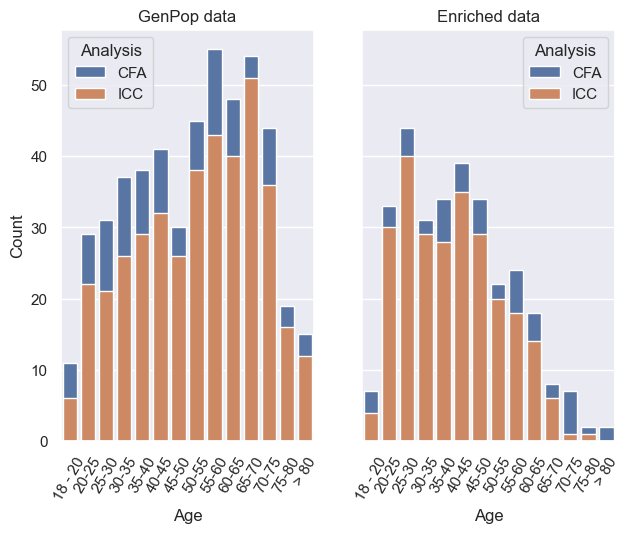

In [24]:
# Plot

# neat labels
labels = ['18 - 20', '20-25', '25-30', '30-35', '35-40', '40-45', '45-50', '50-55', '55-60', '60-65', '65-70', '70-75', '75-80', '> 80']

# plot - version 1 - separately for cfa and icc
fig, axes = plt.subplots(1, 2, sharey=True)
#fig.suptitle('Data split by GenPop vs Enriched')
fig.tight_layout()
sns.set(font_scale=0.9)
sns.set_theme(rc={'figure.figsize':(8, 4)})

ax = sns.barplot(data=age_genpop_cfa, x='binned_ages', y='count', label = 'CFA', ax = axes[0])
ax = sns.barplot(data=age_genpop_icc, x='binned_ages', y='count', label = 'ICC', ax = axes[0])
ax.set(xlabel='Age', ylabel='Count')
ax.legend(title='Analysis') # Add the legend
ax.set_title("GenPop data")
ax.set_xticklabels(labels, rotation=60)

ax = sns.barplot(data=age_enriched_cfa, x='binned_ages', y='count', label = 'CFA', ax = axes[1])
ax = sns.barplot(data=age_enriched_icc, x='binned_ages', y='count', label = 'ICC', ax = axes[1])
ax.set(xlabel='Age', ylabel='Count')
ax.legend(title='Analysis') # Add the legend
ax.set_title("Enriched data")
ax.set_xticklabels(labels, rotation=60)

plt.show()

### --> do the same for validation

In [25]:
bins = [0, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, np.inf]
labels = ['18 - 20', '20-25', '25-30', '30-35', '35-40', '40-45', '45-50', '50-55', '55-60', '60-65', '65-70', '70-75', '75-80', '> 80']
data_val_full['binned_ages'] = pd.cut(data_val_full['age'], bins=bins, labels=labels, right=False) # right=False makes bins left-inclusive
# count bins
valage_data_binned = data_val_full.binned_ages.value_counts().sort_index()
valage_data_binned = valage_data_binned.reset_index()

/var/folders/b9/8rnyb9g11ln_9fy3cn2zscn00000gt/T/ipykernel_89445/2659181093.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=60)
/var/folders/b9/8rnyb9g11ln_9fy3cn2zscn00000gt/T/ipykernel_89445/2659181093.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=60)


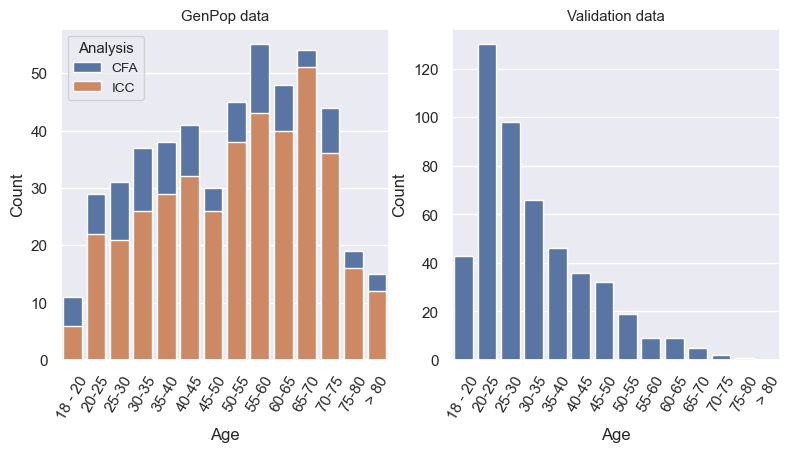

In [26]:
# plot - version 1 - separately for cfa and icc
fig, axes = plt.subplots(1, 2)
#fig.suptitle('Data split by GenPop vs Enriched')
fig.tight_layout()
sns.set(font_scale=0.9)

ax = sns.barplot(data=valage_data_binned, x='binned_ages', y='count')
ax.set(xlabel='Age', ylabel='Count')
ax.set_title("Validation data")
ax.set_xticklabels(labels, rotation=60)

ax = sns.barplot(data=age_genpop_cfa, x='binned_ages', y='count', label = 'CFA', ax = axes[0])
ax = sns.barplot(data=age_genpop_icc, x='binned_ages', y='count', label = 'ICC', ax = axes[0])
ax.set(xlabel='Age', ylabel='Count')
ax.legend(title='Analysis') # Add the legend
ax.set_title("GenPop data")
ax.set_xticklabels(labels, rotation=60)

plt.show()

## Comparison between passed vs failed checks

In [27]:
'''
comparing full data - 
    d_gp_vanilla_full
    d_en_vanilla_full
with all checks removed -
    data_genpop_full_gridall
    data_enriched_full_gridall
'''

'\ncomparing full data - \n    d_gp_vanilla_full\n    d_en_vanilla_full\nwith all checks removed -\n    data_genpop_full_gridall\n    data_enriched_full_gridall\n'

In [28]:
# sanity check

dat_genpop_passed_gridchecks = d_gp_vanilla_full.loc[(d_gp_vanilla_full['passed_grid'] == True) & (d_gp_vanilla_full['passed_grid_recontact'] == True)]
dat_genpop_failed_gridchecks = d_gp_vanilla_full.loc[(d_gp_vanilla_full['passed_grid'] == False) | (d_gp_vanilla_full['passed_grid_recontact'] == False)]

dat_enriched_passed_gridchecks = d_en_vanilla_full.loc[(d_en_vanilla_full['passed_grid'] == True) & (d_en_vanilla_full['passed_grid_recontact'] == True)]
dat_enriched_failed_gridchecks = d_en_vanilla_full.loc[(d_en_vanilla_full['passed_grid'] == False) | (d_en_vanilla_full['passed_grid_recontact'] == False)]


In [29]:
'''
data to work with:
    d_gp_vanilla_full
    dat_genpop_passed_gridcheck
    dat_genpop_failed_gridchecks
    
    d_en_vanilla_full
    dat_enriched_passed_gridcheck
    dat_enriched_failed_gridchecks
'''
# rename data for ease
gp_vanilla = d_gp_vanilla_full.copy(deep=True)
gp_passed = dat_genpop_passed_gridchecks.copy(deep=True)
gp_failed = dat_genpop_failed_gridchecks.copy(deep=True)

en_vanilla = d_en_vanilla_full.copy(deep=True)
en_passed = dat_enriched_passed_gridchecks.copy(deep=True)
en_failed = dat_enriched_failed_gridchecks.copy(deep=True)

In [30]:
def passed_failed_stats(dat_passed, dat_failed):
    # header 
    header_row = ['Comparison measure', 'Passed', 'Failed', 'Statistic', 'p-value']

    # sample sizes
    n_passed = dat_passed.shape[0]
    n_failed = dat_failed.shape[0]

    n_row = ["Sample size", n_passed, n_failed, 'NA', 'NA']

    # compare age
    dat_passed['approx_age'] = 2023 - dat_passed['birthyr']
    dat_failed['approx_age'] = 2023 - dat_failed['birthyr']
        
    age_passed_mean = dat_passed.approx_age.mean()
    age_failed_mean = dat_failed.approx_age.mean()
    age_passed_std = dat_passed.approx_age.std()
    age_failed_std = dat_failed.approx_age.std()
    age_statistic, age_pval = ttest_ind(dat_passed['approx_age'], dat_failed['approx_age'], equal_var=False)  # Welch's t-test

    age_row = ["Age",\
               f"{round(age_passed_mean,2)} ({round(age_passed_std,2)})",\
               f"{round(age_failed_mean,2)} ({round(age_failed_std,2)})",\
               round(age_statistic,3),\
               round(age_pval,3)]

    # compare sex
    d_p=sex_stats(dat=dat_passed, sex_or_gender='sex')
    d_f=sex_stats(dat=dat_failed, sex_or_gender='sex')
    
    m_count_passed, sex_f_passed, sex_f_perc_passed = print_sex_stats(d_p)
    m_count_failed, sex_f_failed, sex_f_perc_failed = print_sex_stats(d_f)

    table = pd.DataFrame({
        "passed": [m_count_passed, sex_f_passed],  # counts in passed
        "failed": [m_count_failed, sex_f_failed]   # counts in failed
    }, index=["Male", "Female"])

    sex_statistic, sex_pval, dof, expected = chi2_contingency(table)

    sex_row = ["Sex",\
               f"{sex_f_passed}({round(sex_f_perc_passed,2)}%)",\
               f"{sex_f_failed}({round(sex_f_perc_failed,2)}%)",\
               round(sex_statistic,3),\
               round(sex_pval,3)]

    # compare bothered_mood
    bmood_passed = float(dat_passed.mood_bothered.value_counts()[True])
    bmood_perc_passed = bmood_passed/float(n_passed)*100
    bmood_failed = float(dat_failed.mood_bothered.value_counts()[True])
    bmood_perc_failed = bmood_failed/float(n_failed)*100

    table = pd.DataFrame({
            "bothered_in_passed": [bmood_passed, float(dat_passed.mood_bothered.value_counts()[False])],  # counts in passed
            "bothered_in_failed": [bmood_failed, float(dat_failed.mood_bothered.value_counts()[False])]   # counts in failed
    }, index=["Bothered_by_dx", "Not_bothered_by_dx"]) 

    bmood_statistic, bmood_pval , dof, expected = chi2_contingency(table)

    bmood_row = ["Bothered by mood",\
                 f"{bmood_passed}({round(bmood_perc_passed,2)}%)",\
                 f"{bmood_failed}({round(bmood_perc_failed,2)}%)",\
                 round(bmood_statistic,3),\
                 round(bmood_pval,3)]

    # compare bothered_anx
    banx_passed = float(dat_passed.anxiety_bothered.value_counts()[True])
    banx_perc_passed = banx_passed/float(n_passed)*100
    banx_failed = float(dat_failed.anxiety_bothered.value_counts()[True])
    banx_perc_failed = banx_failed/float(n_failed)*100

    table = pd.DataFrame({
            "bothered_in_passed": [banx_passed, float(dat_passed.anxiety_bothered.value_counts()[False])],  # counts in passed
            "bothered_in_failed": [banx_failed, float(dat_failed.anxiety_bothered.value_counts()[False])]   # counts in failed
    }, index=["Bothered_by_dx", "Not_bothered_by_dx"]) 

    banx_statistic, banx_pval , dof, expected = chi2_contingency(table)

    banx_row = ["Bothered by anxiety",\
                 f"{banx_passed}({round(banx_perc_passed,2)}%)",\
                 f"{banx_failed}({round(banx_perc_failed,2)}%)",\
                 round(banx_statistic,3),\
             round(banx_pval,3)]

    # compare bothered_adhd
    badhd_passed = float(dat_passed.attention_bothered.value_counts()[True])
    badhd_perc_passed = badhd_passed/float(n_passed)*100
    badhd_failed = float(dat_failed.attention_bothered.value_counts()[True])
    badhd_perc_failed = badhd_failed/float(n_failed)*100

    table = pd.DataFrame({
            "bothered_in_passed": [badhd_passed, float(dat_passed.attention_bothered.value_counts()[False])],  # counts in passed
            "bothered_in_failed": [badhd_failed, float(dat_failed.attention_bothered.value_counts()[False])]   # counts in failed
    }, index=["Bothered_by_dx", "Not_bothered_by_dx"]) 

    badhd_statistic, badhd_pval , dof, expected = chi2_contingency(table)

    badhd_row = ["Bothered by adhd",\
                 f"{badhd_passed}({round(badhd_perc_passed,2)}%)",\
                 f"{badhd_failed}({round(badhd_perc_failed,2)}%)",\
                 round(badhd_statistic,3),\
                 round(badhd_pval,3)]
    return([header_row, n_row, age_row, sex_row, bmood_row, banx_row, badhd_row])

In [31]:
# sanity check
rows_en = passed_failed_stats(en_passed, en_failed)
for row in rows_en:
    print(row)

f = 180 (70.59%), m = 72, other/missing = 3
(sanity check: overall n = 255)
f = 30 (54.55%), m = 25, other/missing = 0
(sanity check: overall n = 55)
['Comparison measure', 'Passed', 'Failed', 'Statistic', 'p-value']
['Sample size', 255, 55, 'NA', 'NA']
['Age', '39.56 (13.01)', '47.38 (18.34)', np.float64(-3.005), np.float64(0.004)]
['Sex', '180(70.59%)', '30(54.55%)', np.float64(5.199), np.float64(0.023)]
['Bothered by mood', '206.0(80.78%)', '32.0(58.18%)', np.float64(11.725), np.float64(0.001)]
['Bothered by anxiety', '200.0(78.43%)', '29.0(52.73%)', np.float64(14.183), np.float64(0.0)]
['Bothered by adhd', '79.0(30.98%)', '10.0(18.18%)', np.float64(3.022), np.float64(0.082)]


In [32]:
# csv

# genpop

with open(log_dir / 'checks_passed_failed_stats_GP.csv', mode='w', newline='') as file:
    writer = csv.writer(file)
    rows_GP = passed_failed_stats(gp_passed, gp_failed)
    for row in rows_GP:
        writer.writerow(row)

# enriched

with open(log_dir / 'checks_passed_failed_stats_EN.csv', mode='w', newline='') as file:
    writer = csv.writer(file)
    rows_EN = passed_failed_stats(en_passed, en_failed)
    for row in rows_EN:
        writer.writerow(row)

f = 214 (53.77%), m = 184, other/missing = 0
(sanity check: overall n = 398)
f = 55 (53.92%), m = 47, other/missing = 0
(sanity check: overall n = 102)
f = 180 (70.59%), m = 72, other/missing = 3
(sanity check: overall n = 255)
f = 30 (54.55%), m = 25, other/missing = 0
(sanity check: overall n = 55)


# Bothered by

In [33]:
def print_bothered(sample, name_to_print):
    n_all = float(sample.shape[0])
    
    n_bothered_mood = float(sample.mood_bothered.value_counts()[True])
    percentage_mood = n_bothered_mood/n_all*100
    n_bothered_anx = float(sample.anxiety_bothered.value_counts()[True])
    percentage_anx = n_bothered_anx/n_all*100
    n_bothered_att = float(sample.attention_bothered.value_counts()[True])
    percentage_att = n_bothered_att/n_all*100  

    print(name_to_print)
    print("\nBothered by mood: {}, which is {} percent of {} samples".format(n_bothered_mood, percentage_mood, n_all))
    print("Bothered by anxiety: {}, which is {} percent of {} samples".format(n_bothered_anx, percentage_anx, n_all))
    print("Bothered by attention: {}, which is {} percent of {} samples\n".format(n_bothered_att, percentage_att, n_all))
   
    return(n_bothered_mood, percentage_mood, n_bothered_anx, percentage_anx, n_bothered_att, percentage_att)

In [34]:
print_bothered(sample=data_genpop_full_gridall, name_to_print="GenPop ICC sample")
print_bothered(sample=data_enriched_full_gridall, name_to_print="Enriched ICC sample")
print_bothered(sample=data_genpop_full_grid1st, name_to_print="GenPop CFA sample")
print_bothered(sample=data_enriched_full_grid1st, name_to_print="Enriched CFA sample")

GenPop ICC sample

Bothered by mood: 74.0, which is 18.592964824120603 percent of 398.0 samples
Bothered by anxiety: 84.0, which is 21.105527638190953 percent of 398.0 samples
Bothered by attention: 23.0, which is 5.778894472361809 percent of 398.0 samples

Enriched ICC sample

Bothered by mood: 206.0, which is 80.7843137254902 percent of 255.0 samples
Bothered by anxiety: 200.0, which is 78.43137254901961 percent of 255.0 samples
Bothered by attention: 79.0, which is 30.980392156862745 percent of 255.0 samples

GenPop CFA sample

Bothered by mood: 96.0, which is 19.3158953722334 percent of 497.0 samples
Bothered by anxiety: 110.0, which is 22.132796780684107 percent of 497.0 samples
Bothered by attention: 33.0, which is 6.639839034205232 percent of 497.0 samples

Enriched CFA sample

Bothered by mood: 235.0, which is 77.04918032786885 percent of 305.0 samples
Bothered by anxiety: 226.0, which is 74.09836065573771 percent of 305.0 samples
Bothered by attention: 89.0, which is 29.180327

(235.0, 77.04918032786885, 226.0, 74.09836065573771, 89.0, 29.18032786885246)

In [35]:
(df_gp1, df_gp2, df_gp3) = load_data("genpop", doing_checks=False, doing_remove_checks=False, rescore=True)
df_gp1.head()

False


,caseid,weight,sample_type,screener_1ongoing,screener_2impact,screener_3depression,screener_4anxiety,screener_5attention,consent,mood_yn,FNM_Q25_1,FNM_Q25_2,FNM_Q25_3,FNM_Q25_4,FNM_Q25_5,FNM_Q25_6,FNM_Q25_955,FNM_Q25_933,FNM_Q25_open1,mood_years,FNM_Q27_1,FNM_Q27_2,FNM_Q27_3,FNM_Q27_4,FNM_Q27_5,FNM_Q27_6,FNM_Q27_7,FNM_Q27_8,FNM_Q27_9,FNM_Q27_10,FNM_Q27_11,FNM_Q27_12,FNM_Q27_13,FNM_Q27_14,FNM_Q27_15,FNM_Q27_16,FNM_Q27_17,FNM_Q27_18,FNM_Q27_19,FNM_Q27_955,FNM_Q27_933,FNM_Q27_open1,mood_bothered_orig,anxiety_yn,FNM_Q30_m_1,FNM_Q30_m_2,FNM_Q30_m_3,FNM_Q30_m_4,FNM_Q30_m_5,FNM_Q30_m_6,FNM_Q30_m_7,FNM_Q30_m_8,FNM_Q30_m_955,FNM_Q30_m_933,FNM_Q30_open1,anxiety_years,FNM_Q32_1,FNM_Q32_2,FNM_Q32_3,FNM_Q32_4,FNM_Q32_5,FNM_Q32_6,FNM_Q32_7,FNM_Q32_8,FNM_Q32_9,FNM_Q32_10,FNM_Q32_955,FNM_Q32_933,FNM_Q32_open1,anxiety_bothered_orig,attention_yn,FNM_Q35_m_1,FNM_Q35_m_2,FNM_Q35_m_3,FNM_Q35_m_933,FNM_Q35_open1,attention_years,FNM_Q37_m_1,FNM_Q37_m_2,FNM_Q37_m_3,FNM_Q37_m_4,FNM_Q37_m_5,FNM_Q37_m_6,FNM_Q37_m_7,FNM_Q37_m_8,FNM_Q37_m_9,FNM_Q37_m_955,FNM_Q37_m_933,FNM_Q37_open1,attention_bothered_orig,inattention_1,inattention_2,inattention_3,inattention_4,inattention_5,inattention_6,FNM_Q1_attn,inattention_7,inattention_8,inattention_9,hyperactivity_1,hyperactivity_2,hyperactivity_3,hyperactivity_4,hyperactivity_5,impulsivity_1,impulsivity_2,impulsivity_3,impulsivity_4,sct_1,sct_2,sct_3,sct_4,sct_5,sct_6,sct_7,sct_8,sct_9,gad_1,gad_2,gad_3,gad_4,gad_5,gad_6,gad_7,phq_1,phq_2,phq_3,phq_4,phq_5,phq_6,phq_7,phq_8,hitop157,hitop81,hitop34,hitop54,hitop243,hitop182,hitop69,hitop89,hitop50,check_moderately,hitop129,hitop265,hitop124,hitop231,hitop93,hitop67,hitop245,hitop281,hitop141,hitop40,hitop204,hitop21,hitop236,hitop280,hitop84,hitop120,hitop77,hitop92,hitop258,hitop39,hitop254,hitop215,hitop95,hitop106,hitop283,hitop16,hitop20,hitop189,hitop1,hitop136,hitop246,hitop248,hitop257,hitop114,hitop117,hitop250,hitop200,hitop160,hitop23,hitop165,hitop244,hitop9,hitop142,hitop230,hitop149,hitop247,hitop99,hitop66,hitop240,hitop222,hitop90,hitop113,hitop278,hitop203,hitop159,hitop123,hitop275,hitop268,hitop225,hitop143,hitop151,hitop181,hitop211,hitop17,hitop126,hitop5,hitop261,hitop220,check_notatall,hitop15,hitop72,hitop140,hitop109,hitop197,hitop104,todayinattention_1,todayinattention_2,todayinattention_3,todayinattention_4,todayinattention_5,todayinattention_6,todayinattention_7,todayinattention_8,todayinattention_9,todayhyperactivity_1,todayhyperactivity_2,todayhyperactivity_3,todayhyperactivity_4,todayhyperactivity_5,todayimpulsivity_1,todayimpulsivity_2,todayimpulsivity_3,todayimpulsivity_4,todaysct_1,todaysct_2,todaysct_3,todaysct_4,todaysct_5,todaysct_6,todaysct_7,todaysct_8,todaysct_9,today_na1,todaygad_1,todaygad_2,todaygad_3,todaygad_4,...,hitop248_recontact,hitop257_recontact,hitop114_recontact,hitop117_recontact,hitop250_recontact,hitop200_recontact,hitop160_recontact,hitop23_recontact,hitop165_recontact,hitop244_recontact,hitop9_recontact,hitop142_recontact,hitop230_recontact,hitop149_recontact,hitop247_recontact,hitop99_recontact,hitop66_recontact,hitop240_recontact,hitop222_recontact,hitop90_recontact,hitop113_recontact,hitop278_recontact,hitop203_recontact,hitop159_recontact,hitop123_recontact,hitop275_recontact,hitop268_recontact,hitop225_recontact,hitop143_recontact,hitop151_recontact,hitop181_recontact,hitop211_recontact,hitop17_recontact,hitop126_recontact,hitop5_recontact,hitop261_recontact,hitop220_recontact,check_notatall_recontact,hitop15_recontact,hitop72_recontact,hitop140_recontact,hitop109_recontact,hitop197_recontact,hitop104_recontact,todayinattention_1_recontact,todayinattention_2_recontact,todayinattention_3_recontact,todayinattention_4_recontact,todayinattention_5_recontact,todayinattention_6_recontact,todayinattention_7_recontact,todayinattention_8_recontact,todayinattention_9_recontact,todayhyperactivity_1_recontact,todayhyperactivity_2_recontact,todayhyperactivity_3_recontact,todayhyperactivity_4_recontact,todayhyperacti

In [36]:
print_bothered(sample=df_gp1, name_to_print="GenPop vanilla no checks removed")

GenPop vanilla no checks removed

Bothered by mood: 96.0, which is 19.2 percent of 500.0 samples
Bothered by anxiety: 111.0, which is 22.2 percent of 500.0 samples
Bothered by attention: 33.0, which is 6.6000000000000005 percent of 500.0 samples



(96.0, 19.2, 111.0, 22.2, 33.0, 6.6000000000000005)